# SILVA Optical Flow: RAFT and DEQ-Flow Bridge

RAFT introduced all-pairs correlation and recurrent flow refinement. DEQ-Flow
casts optical flow as a fixed-point solve. The SILVA package version is compact
and designed for tutorials and compact validation runs:

$$
u^\star=T_\theta(u^\star,I_1,I_2).
$$

<!-- silva-numbered-citations:start -->
**Numbered literature:** [22](https://jseluis.github.io/silva-networks/paper/references/#ref-22), [23](https://jseluis.github.io/silva-networks/paper/references/#ref-23), [24](https://jseluis.github.io/silva-networks/paper/references/#ref-24). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import resolve_device, SolverConfig

torch.manual_seed(11)
np.random.seed(11)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Synthetic Translation Pair

The package generator creates two images and a known forward flow
$u=(u_x,u_y)$. This keeps the notebook small enough for CPU and Colab.

In [3]:
from silva_networks import make_silva_translation_flow_batch

batch = make_silva_translation_flow_batch(
    batch_size=1,
    channels=1,
    height=12,
    width=12,
    shift=(0.75, 0.25),
    device=device,
)
batch.image1.shape, batch.image2.shape, batch.flow[:, :, 0, 0]

(torch.Size([1, 1, 12, 12]),
 torch.Size([1, 1, 12, 12]),
 tensor([[0.7500, 0.2500]]))

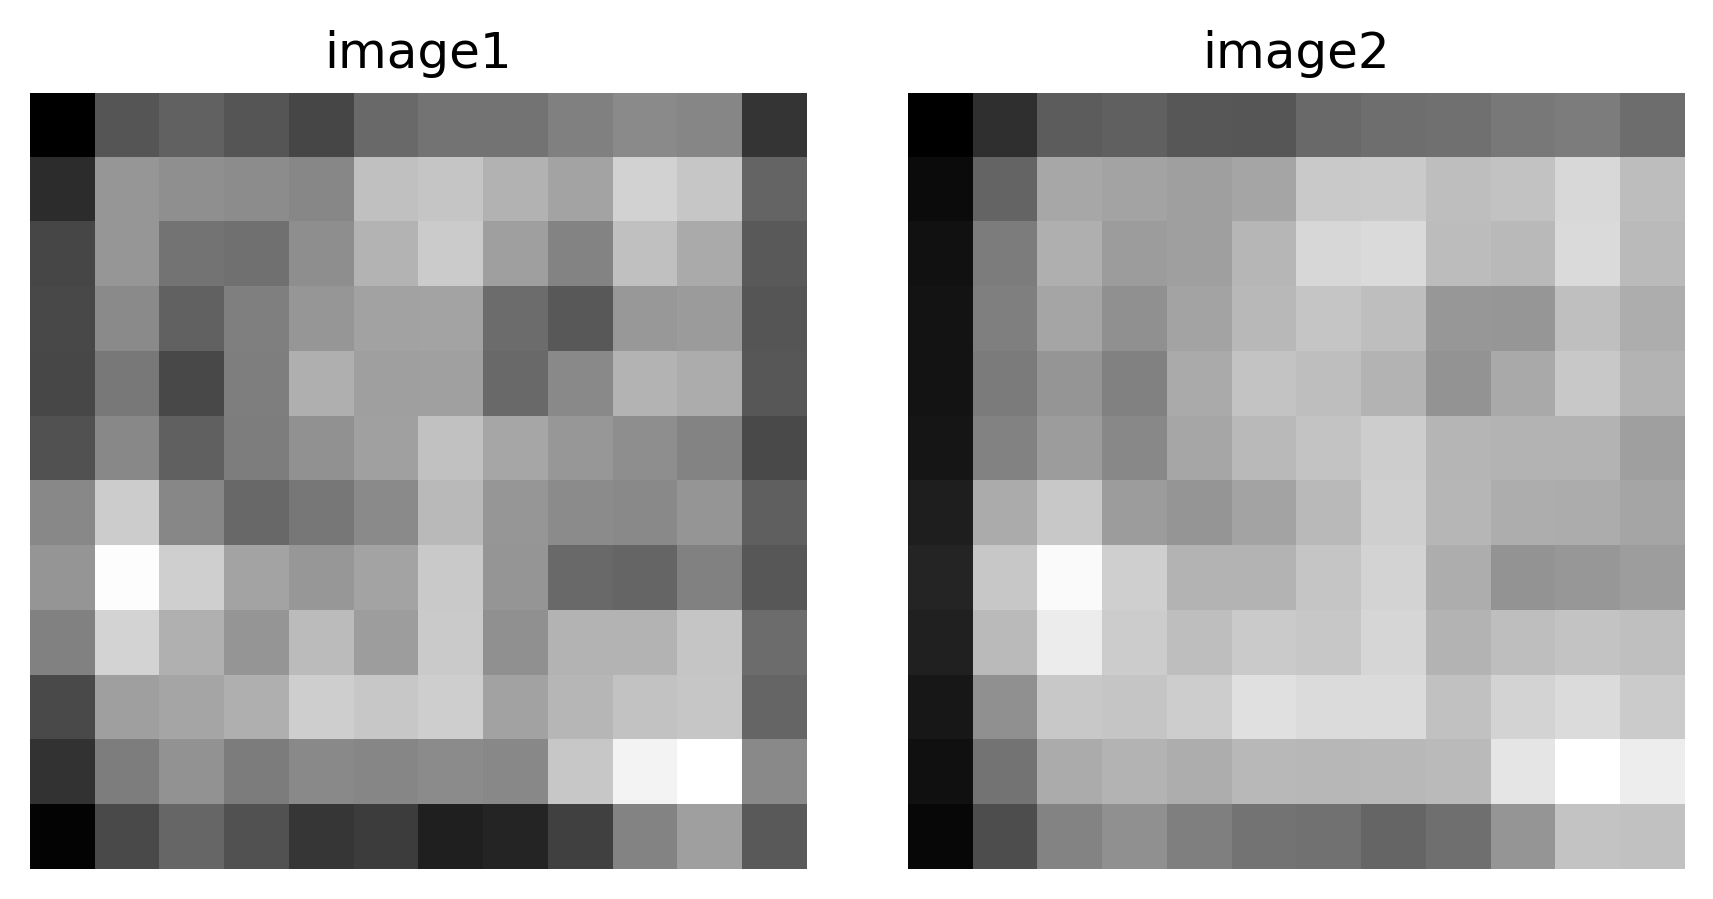

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(batch.image1[0, 0].detach().cpu(), cmap="gray")
axes[0].set_title("image1")
axes[1].imshow(batch.image2[0, 0].detach().cpu(), cmap="gray")
axes[1].set_title("image2")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

## Correlation and Local Lookup

Given feature maps $F_1,F_2$,

$$
C_{i,j,k,\ell}
=
\frac{\langle F_{1,:,i,j},F_{2,:,k,\ell}\rangle}{\sqrt C}.
$$

In [5]:
from silva_networks import (
    SILVAFlowFeatureEncoder,
    silva_all_pairs_correlation,
    silva_local_correlation_lookup,
)

encoder = SILVAFlowFeatureEncoder(in_channels=1, feature_dim=4).to(device)
f1 = encoder(batch.image1)
f2 = encoder(batch.image2)
corr = silva_all_pairs_correlation(f1, f2)
local = silva_local_correlation_lookup(corr, torch.zeros_like(batch.flow), radius=1)
corr.shape, local.shape

(torch.Size([1, 12, 12, 12, 12]), torch.Size([1, 9, 12, 12]))

## Flow Fixed Point

The transition has the form

$$
T_\theta(u)
=
u+\gamma\tanh\Delta_\theta(u,F_1,\tilde F_2,F_1-\tilde F_2,C[u]).
$$

In [6]:
from silva_networks import (
    silva_deq_flow,
    silva_endpoint_error,
    silva_flow_smoothness_loss,
)

model = silva_deq_flow(
    feature_dim=4,
    hidden_dim=10,
    corr_radius=1,
    update_scale=0.2,
    config=SolverConfig(solver="picard", max_iter=5, alpha=0.4),
).to(device)

result = model(batch.image1, batch.image2, return_result=True, return_correlation=True)
epe = silva_endpoint_error(result.flow, batch.flow, batch.valid)
smooth = silva_flow_smoothness_loss(result.flow)
float(epe.detach().cpu()), float(smooth.detach().cpu()), result.solver_result.residuals

(0.8080268502235413,
 0.004936933517456055,
 [0.19798249006271362,
  0.19794407486915588,
  0.19790738821029663,
  0.19787244498729706,
  0.19783923029899597])

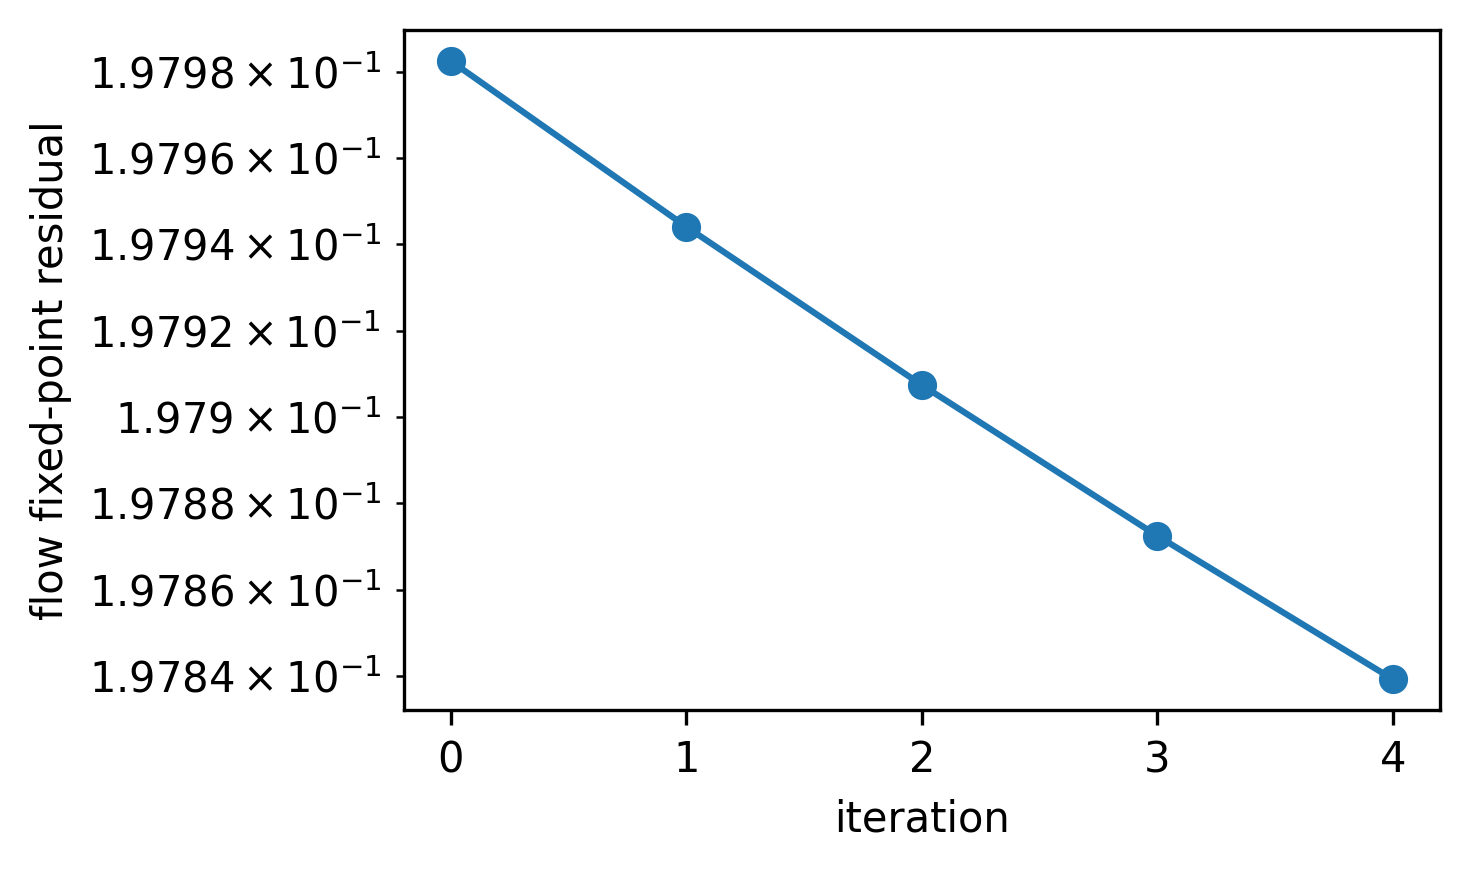

In [7]:
plt.figure(figsize=(5.0, 3.0))
plt.plot(result.solver_result.residuals, marker="o")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("flow fixed-point residual")
plt.tight_layout()

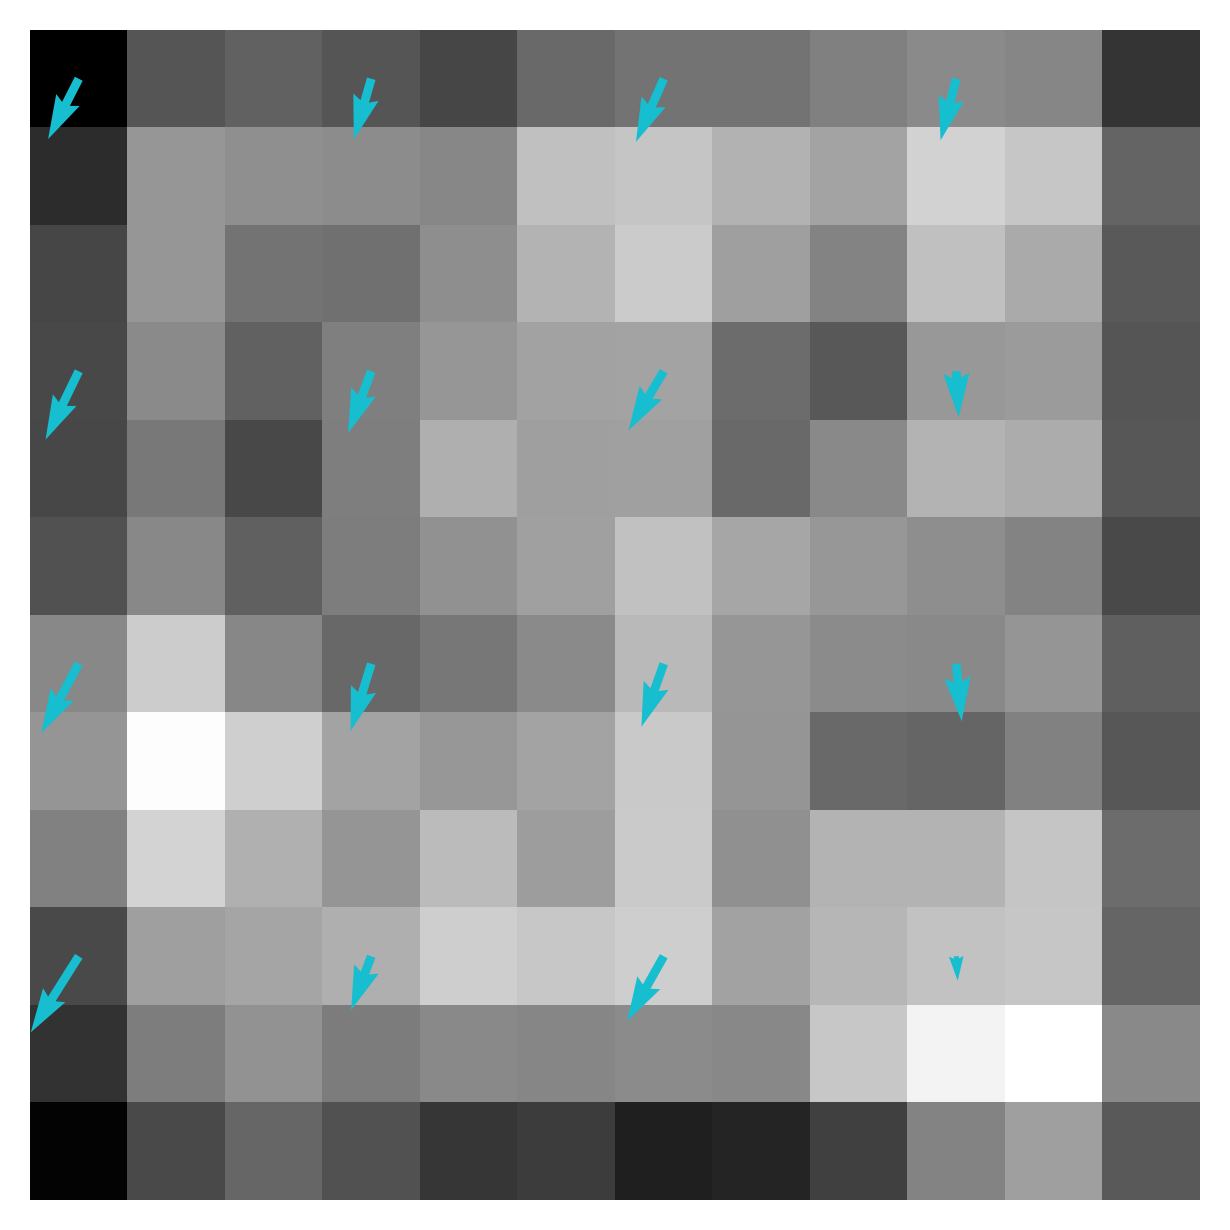

In [8]:
flow = result.flow[0].detach().cpu()
step = 3
y, x_grid = np.mgrid[0:flow.shape[1]:step, 0:flow.shape[2]:step]
u = flow[0, ::step, ::step].numpy()
v = flow[1, ::step, ::step].numpy()
plt.figure(figsize=(4.2, 4.2))
plt.imshow(batch.image1[0, 0].detach().cpu(), cmap="gray")
plt.quiver(x_grid, y, u, v, color="tab:cyan")
plt.axis("off")
plt.tight_layout()

## One Training Step

The model is an ordinary PyTorch module. A supervised validation loss can combine
endpoint error and smoothness.

In [9]:
optim = torch.optim.Adam(model.parameters(), lr=1e-2)
optim.zero_grad()
train_result = model(batch.image1, batch.image2, return_result=True)
loss = silva_endpoint_error(train_result.flow, batch.flow, batch.valid)
loss = loss + 0.01 * silva_flow_smoothness_loss(train_result.flow)
loss.backward()
optim.step()
float(loss.detach().cpu()), model.update.net[-1].weight.grad is not None

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


(0.8080762028694153, True)

## Citation and Sources

If this package or notebook is used, cite:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.1.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work uses SILVA methodology, also cite:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Additional sources for this notebook:

- TorchDEQ: https://github.com/locuslab/torchdeq
- Deep Equilibrium Optical Flow Estimation: https://arxiv.org/abs/2204.08442
- DEQ-Flow: https://github.com/locuslab/deq-flow
- RAFT: https://arxiv.org/abs/2003.12039
- RAFT repository: https://github.com/princeton-vl/RAFT

The implementation used here is package-native and follows the package solver API.

## Where to Go Next

| Question | Page |
| --- | --- |
| How is equilibrium optical flow derived? | [DEQ Engine and Optical Flow](https://jseluis.github.io/silva-networks/learn/deq-engine-and-flow/) |
| Where is the compact flow model executed as a script? | [Optical Flow SILVA Example](https://jseluis.github.io/silva-networks/examples/optical-flow-silva/) |
| Which flow modules and losses are public? | [Optical Flow API](https://jseluis.github.io/silva-networks/api/flow/) |
